# Home Credit Default Risk
**Following the Hands-On ML checklist — Aurélien Géron**

## Introduction

**Initial question:** Can we predict a client's repayment ability using alternative data, so that creditworthy clients who lack formal credit history are not rejected and receive loan terms that set them up for success?

Many people struggle to get loans due to insufficient or non-existent credit histories. This population is often taken advantage of by untrustworthy lenders. Home Credit strives to broaden financial inclusion for the unbanked by providing a positive and safe borrowing experience. To assess repayment ability, they use alternative data such as telco and transactional information.

In this notebook we tackle the Kaggle competition where Home Credit challenges us to unlock the full potential of their data. The task is a supervised binary classification problem — predicting whether a client will default (1) or not (0) — evaluated using **ROC-AUC** and **F1 Score** with k-fold cross-validation.

In [ ]:
import sys
from pathlib import Path

# Locate repo root — works whether running locally or on Binder/Colab
_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.git').exists()), Path('../../'))
sys.path.insert(0, str(_root / 'src'))

from data_loader import ensure_data, PROCESSED_DIR
ensure_data()

# loading the data
df = pd.read_csv(PROCESSED_DIR / 'application_train.csv')

## Data Preprossesing

Lets first get an idea of our Dataframe

In [2]:
df.shape[0], df.shape[1]

(307511, 122)

Seeing that we have a lot of rows, we now know that we will have to be carefull with computing intense processes

First step should always be to find Collumns that dont carry any information, the easiest way to do this is by a low variance function

In [3]:
cols_to_drop = [col for col in df.columns if df[col].value_counts(normalize=True).values[0] > 0.95]
df.drop(columns=cols_to_drop, inplace=True)

# to visualize the amount of remaining columns
df.shape[1]

96

Next in the data we have many collumns with avg, median and mode marking. Since median is most robust, we will keep it and drop the rest

In [4]:
#for loop to search for avg and mode collumns and drop them
cols_to_drop = [col for col in df.columns if '_AVG' in col or '_MODE' in col]
df.drop(columns=cols_to_drop, inplace=True)

df.shape[1]

65

It would be reasonable to now see which features might be so incomplete that analyzing them would be unreasonable to check this we use following code

In [5]:
df.isnull().mean()

SK_ID_CURR                    0.000000
TARGET                        0.000000
NAME_CONTRACT_TYPE            0.000000
CODE_GENDER                   0.000000
FLAG_OWN_CAR                  0.000000
                                ...   
FLAG_DOCUMENT_6               0.000000
FLAG_DOCUMENT_8               0.000000
AMT_REQ_CREDIT_BUREAU_MON     0.135016
AMT_REQ_CREDIT_BUREAU_QRT     0.135016
AMT_REQ_CREDIT_BUREAU_YEAR    0.135016
Length: 65, dtype: float64

Realizing that only these 3 have nan values, I did some further research. These collums are about asking for reports in the credit bureau which were probably not filed and thus are nan so we can fill them with 0. we dropped before collumns that were smaller increments of hour, day, week. so further I will check the correlation of these to the default risk

In [6]:
# I ran into an issue with this column, so I will convert it to numeric and fill the NaN values with 0
cols = [col for col in df.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

I would like to check now if these features deviate significantly for the default risk

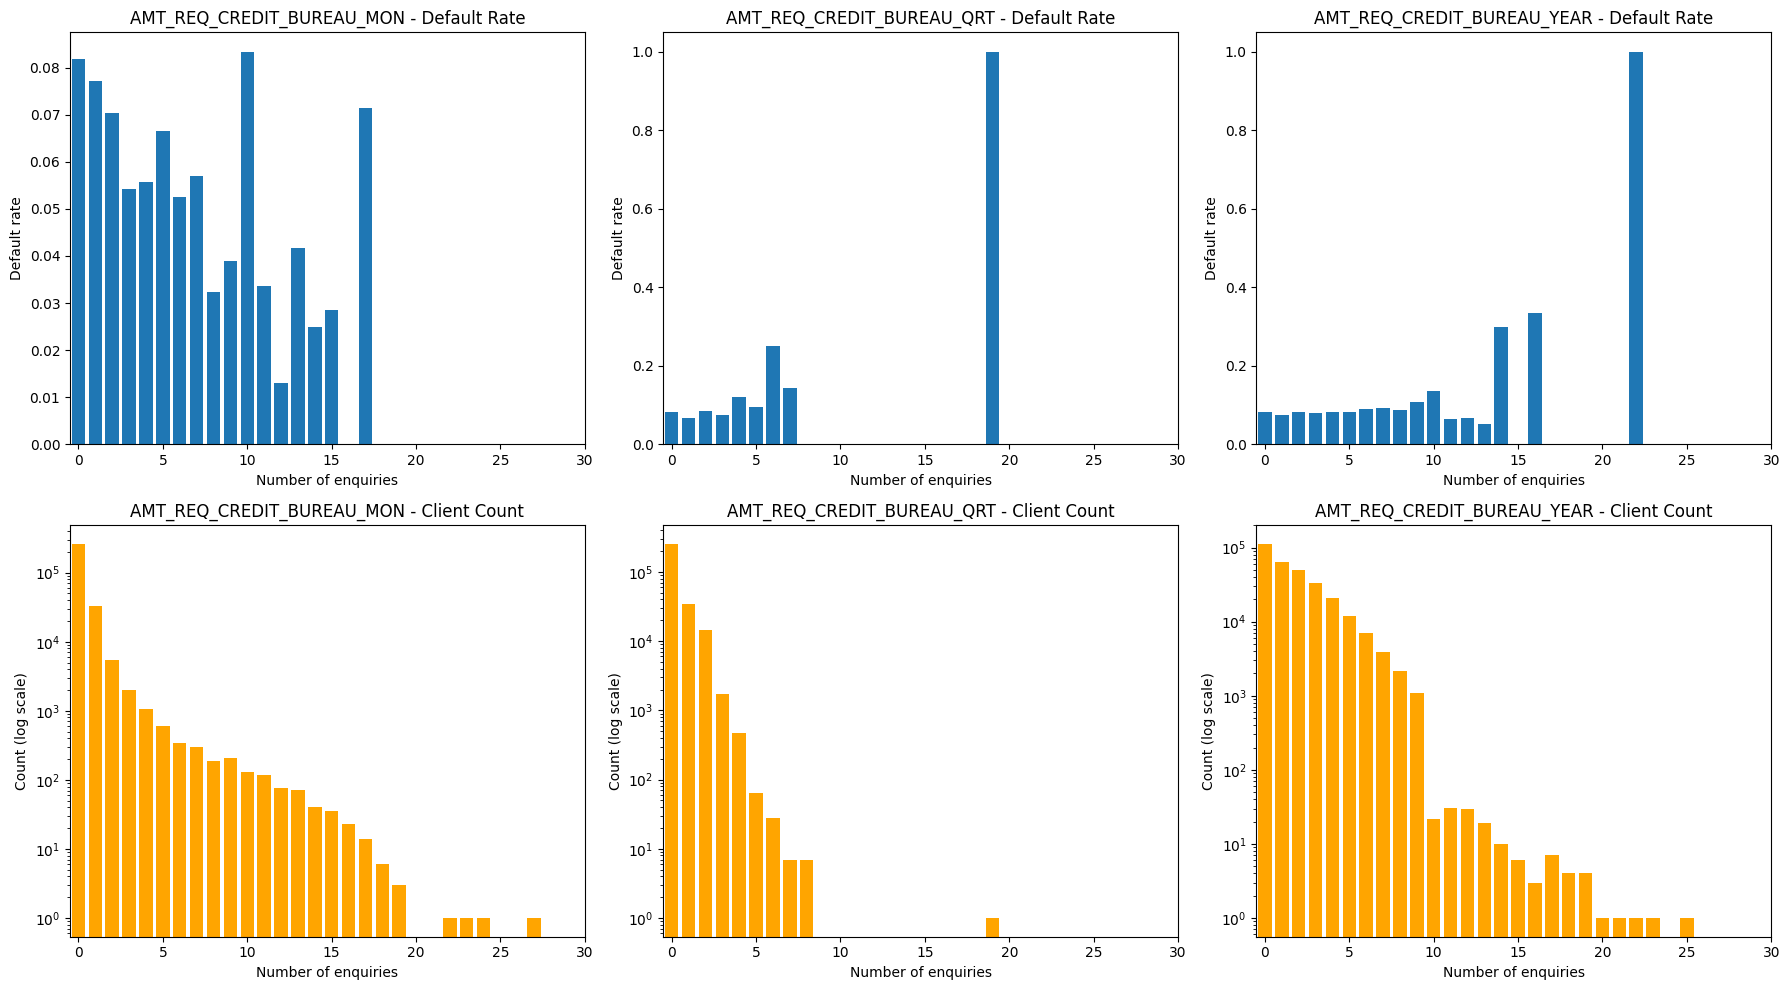

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(cols):
    grouped = df.groupby(col)['TARGET'].agg(['mean', 'count'])
    
    # Default rate
    axes[0, i].bar(grouped.index, grouped['mean'])
    axes[0, i].set_title(f'{col} - Default Rate')
    axes[0, i].set_xlabel('Number of enquiries')
    axes[0, i].set_ylabel('Default rate')
    axes[0, i].set_xlim(-0.5, 30)

    # Client count (log scale)
    axes[1, i].bar(grouped.index, grouped['count'], color='orange')
    axes[1, i].set_title(f'{col} - Client Count')
    axes[1, i].set_xlabel('Number of enquiries')
    axes[1, i].set_ylabel('Count (log scale)')
    axes[1, i].set_yscale('log')
    axes[1, i].set_xlim(-0.5, 30)

plt.tight_layout()
plt.show()



After seeing the trends I suggest these parameters are just noise so they need to be dropped

In [8]:
cols_to_drop = [col for col in df.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
df.drop(columns=cols_to_drop, inplace=True)

df.shape[1]

62

Now we need to remove categorical/ordinal features 

In [9]:
df.select_dtypes(include='object').nunique()

C:\Users\simon\AppData\Local\Temp\ipykernel_11248\3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
dtype: int64

So now we have the data frame and we know the features that are not numerical so that we can change them to be used later for any kind of correlational calculations. It is found that 2 of them are to big to for example one hot encode them so lets try to manually find out how important they are

For that I will group them and see if there are any outliers for defaulting

<Axes: xlabel='ORGANIZATION_TYPE'>

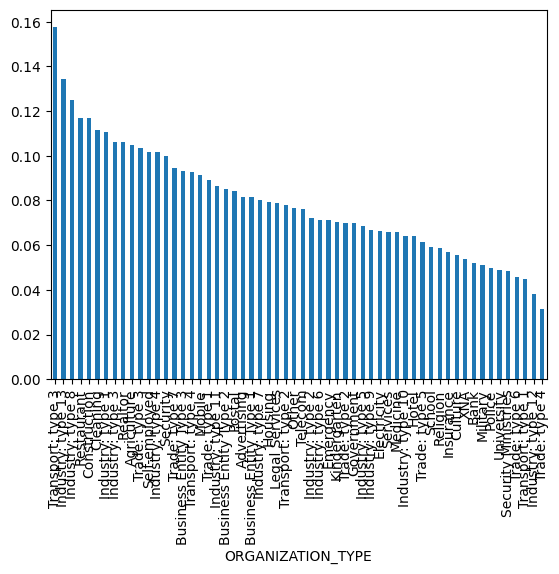

In [10]:
df.groupby('ORGANIZATION_TYPE')['TARGET'].mean().sort_values(ascending=False).plot(kind='bar')

In [11]:
df.groupby('ORGANIZATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

ORGANIZATION_TYPE
Transport: type 3         0.157540
Industry: type 13         0.134328
Industry: type 8          0.125000
Restaurant                0.117062
Construction              0.116798
Cleaning                  0.111538
Industry: type 1          0.110683
Industry: type 3          0.106162
Realtor                   0.106061
Agriculture               0.104727
Trade: type 3             0.103379
Self-employed             0.101739
Industry: type 4          0.101482
Security                  0.099784
Trade: type 7             0.094496
Business Entity Type 3    0.092996
Transport: type 4         0.092812
Mobile                    0.091483
Trade: type 1             0.089080
Industry: type 11         0.086538
Business Entity Type 2    0.085284
Postal                    0.084376
Advertising               0.081585
Business Entity Type 1    0.081384
Industry: type 7          0.080337
Housing                   0.079446
Legal Services            0.078689
Transport: type 2         0.078040
Ot

In [12]:
#since xna is a missing value, we will find out how many missing values there are
df[df['ORGANIZATION_TYPE'] == 'XNA'].shape[0]

55374

The XNA makes up 18% of the whole data, so its important to be kept

After my analysis, I would bucket into high, mid and low risk where the cuts are at 10 and 6% 

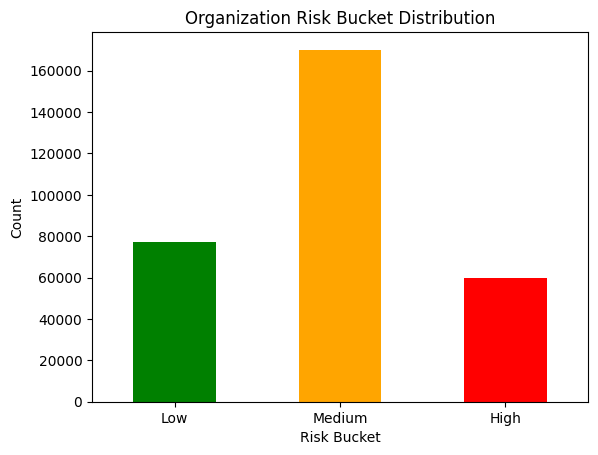

In [13]:
org_risk = df.groupby('ORGANIZATION_TYPE')['TARGET'].mean()
df['ORG_RISK_BUCKET'] = df['ORGANIZATION_TYPE'].map(org_risk)
df['ORG_RISK_BUCKET'] = pd.cut(df['ORG_RISK_BUCKET'], bins=[0, 0.06, 0.10, 1], labels=[0, 1, 2]).astype(int)
df.drop(columns=['ORGANIZATION_TYPE'], inplace=True)


df['ORG_RISK_BUCKET'].value_counts().sort_index().plot(kind='bar', color=['green', 'orange', 'red'])
plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'], rotation=0)
plt.title('Organization Risk Bucket Distribution')
plt.xlabel('Risk Bucket')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='OCCUPATION_TYPE'>

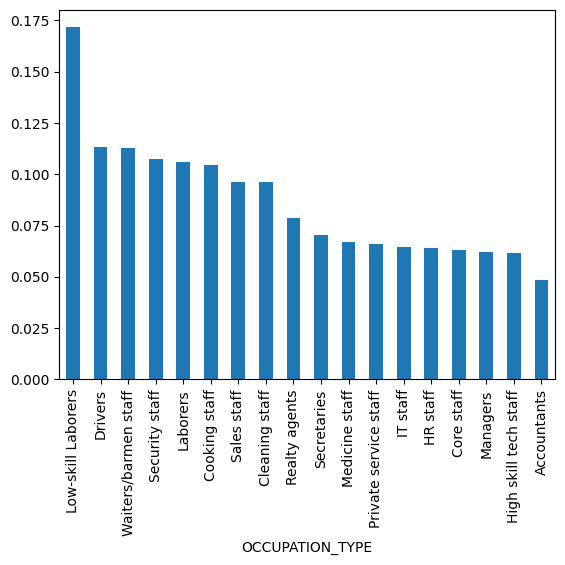

In [14]:
df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False).plot(kind='bar')

After running into an Issue with nan values, I am going to check for them

In [15]:
df['OCCUPATION_TYPE'].isnull().sum()


np.int64(96391)

96391 is over 30% of the data, which is a bit to much, so we are going to drop them

In [16]:
df.drop(columns=['OCCUPATION_TYPE'], inplace=True)

In [17]:
df.shape[1] 

61

In [18]:
#Lets check for object type columns again
df.select_dtypes(include='object').nunique()

C:\Users\simon\AppData\Local\Temp\ipykernel_11248\708984219.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


NAME_CONTRACT_TYPE            2
CODE_GENDER                   3
FLAG_OWN_CAR                  2
FLAG_OWN_REALTY               2
NAME_TYPE_SUITE               7
NAME_INCOME_TYPE              8
NAME_EDUCATION_TYPE           5
NAME_FAMILY_STATUS            6
NAME_HOUSING_TYPE             6
WEEKDAY_APPR_PROCESS_START    7
dtype: int64

So now that we cleaned the big groups, we can now focus on one hot encoding the rest

In [19]:
#one hot encoding the remaining object type columns
df = pd.get_dummies(df, drop_first=True)

In [20]:
#Checking again for object type columns
df.select_dtypes(include='object').nunique()

Series([], dtype: float64)

Now we are clear for actual data evaluation. Lets find correlations now

In [21]:
df.corr()['TARGET'].sort_values(ascending=False)

TARGET                                  1.000000
DAYS_BIRTH                              0.078239
ORG_RISK_BUCKET                         0.064043
REGION_RATING_CLIENT_W_CITY             0.060893
REGION_RATING_CLIENT                    0.058899
                                          ...   
NAME_INCOME_TYPE_Pensioner             -0.046209
NAME_EDUCATION_TYPE_Higher education   -0.056593
EXT_SOURCE_1                           -0.155317
EXT_SOURCE_2                           -0.160472
EXT_SOURCE_3                           -0.178919
Name: TARGET, Length: 89, dtype: float64

What is EXT_SOURCE_1, Its the external evaluation of clients and has the highest correlation. Negative it is because the higher the score the less likely they are to default.

In [ ]:
#another quick size check
df.shape[1]


89

In [ ]:
#lets continue with the correlation matrix to find highly correlated features to drop
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3)) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.8]
high_corr.sort(key=lambda x: -x[2])
high_corr[:20]

[('FLAG_EMP_PHONE', 'DAYS_EMPLOYED', np.float64(1.0)),
 ('NAME_INCOME_TYPE_Pensioner', 'DAYS_EMPLOYED', np.float64(1.0)),
 ('NAME_INCOME_TYPE_Pensioner', 'FLAG_EMP_PHONE', np.float64(1.0)),
 ('OBS_60_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE', np.float64(0.998)),
 ('AMT_GOODS_PRICE', 'AMT_CREDIT', np.float64(0.987)),
 ('REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT', np.float64(0.951)),
 ('LIVINGAPARTMENTS_MEDI', 'APARTMENTS_MEDI', np.float64(0.942)),
 ('LIVINGAREA_MEDI', 'APARTMENTS_MEDI', np.float64(0.916)),
 ('NAME_EDUCATION_TYPE_Secondary / secondary special',
  'NAME_EDUCATION_TYPE_Higher education',
  np.float64(0.888)),
 ('LIVINGAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', np.float64(0.885)),
 ('CNT_FAM_MEMBERS', 'CNT_CHILDREN', np.float64(0.879)),
 ('LIVINGAREA_MEDI', 'ELEVATORS_MEDI', np.float64(0.868)),
 ('DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', np.float64(0.861)),
 ('ELEVATORS_MEDI', 'APARTMENTS_MEDI', np.float64(0.837)),
 ('LIVE_CITY_NOT_WORK_CITY', 'REG_CI

We find a few data points that highly correlate. DAYS_EMPLOYED already for example tells us if someone is a pensioneer or not and if they have a work phone. The best way to drop is to find the best correlation

In [30]:
# Get correlation with TARGET for all features
target_corr = df.corr()['TARGET'].abs()

cols_to_drop = []

# For each highly correlated pair, show which has stronger target correlation
for col1, col2, corr_val in high_corr:
    corr1 = target_corr.get(col1, 0)
    corr2 = target_corr.get(col2, 0)
    keep = col1 if corr1 >= corr2 else col2
    drop = col2 if corr1 >= corr2 else col1
    print(f"Pair ({corr_val}): keep '{keep}' ({round(max(corr1,corr2),4)}), drop '{drop}' ({round(min(corr1,corr2),4)})")
    cols_to_drop.append(drop)

# Drop duplicates in case same column appears multiple times
cols_to_drop = list(set(cols_to_drop))
df.drop(columns=cols_to_drop, inplace=True)


Pair (1.0): keep 'FLAG_EMP_PHONE' (0.046), drop 'DAYS_EMPLOYED' (0.0449)
Pair (1.0): keep 'NAME_INCOME_TYPE_Pensioner' (0.0462), drop 'DAYS_EMPLOYED' (0.0449)
Pair (1.0): keep 'NAME_INCOME_TYPE_Pensioner' (0.0462), drop 'FLAG_EMP_PHONE' (0.046)
Pair (0.998): keep 'OBS_30_CNT_SOCIAL_CIRCLE' (0.0091), drop 'OBS_60_CNT_SOCIAL_CIRCLE' (0.009)
Pair (0.987): keep 'AMT_GOODS_PRICE' (0.0396), drop 'AMT_CREDIT' (0.0304)
Pair (0.951): keep 'REGION_RATING_CLIENT_W_CITY' (0.0609), drop 'REGION_RATING_CLIENT' (0.0589)
Pair (0.942): keep 'APARTMENTS_MEDI' (0.0292), drop 'LIVINGAPARTMENTS_MEDI' (0.0246)
Pair (0.916): keep 'LIVINGAREA_MEDI' (0.0327), drop 'APARTMENTS_MEDI' (0.0292)
Pair (0.888): keep 'NAME_EDUCATION_TYPE_Higher education' (0.0566), drop 'NAME_EDUCATION_TYPE_Secondary / secondary special' (0.0498)
Pair (0.885): keep 'LIVINGAREA_MEDI' (0.0327), drop 'LIVINGAPARTMENTS_MEDI' (0.0246)
Pair (0.879): keep 'CNT_CHILDREN' (0.0192), drop 'CNT_FAM_MEMBERS' (0.0093)
Pair (0.868): keep 'ELEVATORS_

In [31]:
df.shape[1]

77

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

class DropIDColumns(BaseEstimator, TransformerMixin):
    """Drop SK_ID columns — identifiers with no predictive value."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        cols = [col for col in X.columns if 'SK_ID' in col]
        return X.drop(columns=cols)


class DropLowVariance(BaseEstimator, TransformerMixin):
    """Drop columns where one value dominates more than 95% of rows."""
    def fit(self, X, y=None):
        self.cols_to_drop_ = [
            col for col in X.columns
            if X[col].value_counts(normalize=True).iloc[0] > 0.95
        ]
        return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])


class DropRedundantAggregations(BaseEstimator, TransformerMixin):
    """Drop _AVG and _MODE building columns — keep _MEDI (median is more robust)."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        cols = [col for col in X.columns if '_AVG' in col or '_MODE' in col]
        return X.drop(columns=[c for c in cols if c in X.columns])


class DropNoisyColumns(BaseEstimator, TransformerMixin):
    """Drop AMT_REQ_CREDIT_BUREAU columns — shown to be noise with no meaningful signal."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        cols = [col for col in X.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
        return X.drop(columns=[c for c in cols if c in X.columns])


class BucketAndEncodeObjects(BaseEstimator, TransformerMixin):
    """
    Handle object (categorical) columns:
    - If >30% NaN → drop column
    - If >10 unique values → bucketize by target default rate into low/mid/high (0/1/2)
    - If ≤10 unique values → one-hot encode
    """
    def fit(self, X, y):
        self.cols_to_drop_ = []
        self.bucket_maps_ = {}
        self.ohe_cols_ = []
        obj_cols = X.select_dtypes(include='object').columns

        for col in obj_cols:
            missing_rate = X[col].isnull().mean()
            if missing_rate > 0.30:
                self.cols_to_drop_.append(col)
                continue
            n_unique = X[col].nunique()
            if n_unique > 10:
                filled = X[col].fillna('MISSING')
                rates = filled.groupby(filled).apply(lambda s: y[s.index].mean())
                thresholds = rates.quantile([1/3, 2/3]).values
                bucket_map = {}
                for cat, rate in rates.items():
                    if rate <= thresholds[0]:
                        bucket_map[cat] = 0
                    elif rate <= thresholds[1]:
                        bucket_map[cat] = 1
                    else:
                        bucket_map[cat] = 2
                self.bucket_maps_[col] = bucket_map
            else:
                self.ohe_cols_.append(col)
        return self

    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        for col, bucket_map in self.bucket_maps_.items():
            if col in X.columns:
                X[col] = X[col].fillna('MISSING').map(bucket_map).fillna(1).astype(int)
        ohe_cols = [c for c in self.ohe_cols_ if c in X.columns]
        if ohe_cols:
            X = pd.get_dummies(X, columns=ohe_cols, drop_first=True)
        return X


class DropHighlyCorrelated(BaseEstimator, TransformerMixin):
    """For each highly correlated pair (>threshold), drop the one with weaker target correlation."""
    def __init__(self, threshold=0.8):
        self.threshold = threshold

    def fit(self, X, y):
        df = X.copy()
        df['_TARGET'] = y.values
        corr_matrix = df.corr().abs()
        target_corr = corr_matrix['_TARGET']
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.cols_to_drop_ = set()
        for col in upper.columns:
            for row in upper.index:
                val = upper.loc[row, col]
                if pd.notna(val) and val > self.threshold and col != '_TARGET' and row != '_TARGET':
                    drop = col if target_corr.get(col, 0) <= target_corr.get(row, 0) else row
                    self.cols_to_drop_.add(drop)
        self.cols_to_drop_.discard('_TARGET')
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])

## Preprocessing Pipeline

Now that we have explored and understood the data, we will convert all preprocessing steps into a reusable sklearn Pipeline. This ensures the exact same transformations are applied to both train and test data without any data leakage.

In [ ]:
# Assemble and fit the pipeline
preprocessing = Pipeline([
    ('drop_ids',          DropIDColumns()),
    ('drop_low_variance', DropLowVariance()),
    ('drop_aggregations', DropRedundantAggregations()),
    ('drop_noisy',        DropNoisyColumns()),
    ('encode_objects',    BucketAndEncodeObjects()),
    ('drop_correlated',   DropHighlyCorrelated(threshold=0.8)),
])

X_processed      = preprocessing.fit_transform(X_train, y_train)
X_test_processed = preprocessing.transform(df_test_raw)

print(f"Train processed: {X_processed.shape}")
print(f"Test processed:  {X_test_processed.shape}")

In [ ]:
# Load raw data — pipeline starts from scratch
from data_loader import RAW_DIR  # already set up above

df_train_raw = pd.read_csv(RAW_DIR / 'application_train.csv')
df_test_raw  = pd.read_csv(RAW_DIR / 'application_test.csv')

y_train = df_train_raw['TARGET']
X_train = df_train_raw.drop(columns=['TARGET'])

print(f"Raw train: {X_train.shape}, Raw test: {df_test_raw.shape}")